#Customer Churn Prediction System
###Project Objective

The objective of this project is to build a Machine Learning-based Customer Churn Prediction System using customer behavior and subscription data.

The system aims to predict whether a customer is likely to leave a company or continue using its service. It uses information such as age, tenure, usage frequency, support calls, payment delays, subscription type, contract length, total spending, and recent interaction behavior.

This project simulates a real-world customer retention system where companies can identify customers at higher risk of leaving and take appropriate retention actions before the customer churns.

#TASK 1: Load and Understand the Dataset

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving customer_churn_dataset-testing-master.csv to customer_churn_dataset-testing-master.csv


LIBRARIES

In [2]:
# Import all required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the dataset

df = pd.read_csv("customer_churn_dataset-testing-master.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (64374, 12)


In [4]:
# TASK 1: Load and Understand the Dataset

print("=" * 70)
print("FIRST 5 RECORDS")
print("=" * 70)
display(df.head())

print("=" * 70)
print("LAST 5 RECORDS")
print("=" * 70)
display(df.tail())

print("=" * 70)
print("RANDOM 5 RECORDS")
print("=" * 70)
display(df.sample(5, random_state=42))

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print("Total Customers:", df.shape[0])
print("Total Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nTarget Variable: Churn")
print("Target Values:")
print(df["Churn"].value_counts().sort_index())

print("\n" + "=" * 70)
print("COLUMN UNDERSTANDING")
print("=" * 70)

column_info = {
    "CustomerID": "Unique customer identifier",
    "Age": "Customer demographic information",
    "Gender": "Customer demographic information",
    "Tenure": "Length of customer relationship",
    "Usage Frequency": "Customer usage behavior",
    "Support Calls": "Customer support behavior",
    "Payment Delay": "Payment behavior",
    "Subscription Type": "Subscription information",
    "Contract Length": "Contract information",
    "Total Spend": "Customer spending behavior",
    "Last Interaction": "Recent customer interaction behavior",
    "Churn": "Target variable indicating customer churn"
}

for column, description in column_info.items():
    print(f"{column}: {description}")

print("\n" + "=" * 70)
print("OBSERVATION")
print("=" * 70)

churned = (df["Churn"] == 1).sum()
stayed = (df["Churn"] == 0).sum()

print(f"The dataset contains {df.shape[0]:,} customer records and {df.shape[1]} columns.")
print(f"{churned:,} customers have churned and {stayed:,} customers have stayed.")
print("CustomerID is an identifier and Churn is the target variable.")
print("The remaining features represent customer demographics, usage behavior,")
print("payment behavior, subscription information, spending, and interaction.")
print("Churn = 1 represents a churned customer, while Churn = 0 represents a customer who stayed.")

FIRST 5 RECORDS


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


LAST 5 RECORDS


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1
64373,64374,52,Female,45,15,9,25,Standard,Monthly,696,22,1


RANDOM 5 RECORDS


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
15476,15477,55,Male,20,24,4,6,Standard,Monthly,635,25,0
34666,34667,28,Male,27,30,4,5,Premium,Quarterly,631,10,0
50474,50475,65,Female,60,17,7,16,Premium,Quarterly,314,1,1
7984,7985,53,Male,47,16,8,7,Premium,Annual,527,13,0
20227,20228,32,Male,56,5,7,15,Premium,Annual,236,25,0


DATASET INFORMATION
Total Customers: 64374
Total Columns: 12

Column Names:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Target Variable: Churn
Target Values:
Churn
0    33881
1    30493
Name: count, dtype: int64

COLUMN UNDERSTANDING
CustomerID: Unique customer identifier
Age: Customer demographic information
Gender: Customer demographic information
Tenure: Length of customer relationship
Usage Frequency: Customer usage behavior
Support Calls: Customer support behavior
Payment Delay: Payment behavior
Subscription Type: Subscription information
Contract Length: Contract information
Total Spend: Customer spending behavior
Last Interaction: Recent customer interaction behavior
Churn: Target variable indicating customer churn

OBSERVATION
The dataset contains 64,374 customer records and 12 columns.
30,493 customers have churned and 33,881 customers have st

#TASK 2 — Basic Data Inspection

In [5]:
# TASK 2: Basic Data Inspection

print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)
print(df.columns.tolist())


print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
print(df.dtypes)


print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)
print(df.isnull().sum())


print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)
print("Number of duplicate records:", df.duplicated().sum())


print("\n" + "=" * 70)
print("UNIQUE VALUES")
print("=" * 70)
print(df.nunique())


print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
display(df.describe())


print("\n" + "=" * 70)
print("CHURN DISTRIBUTION")
print("=" * 70)

churn_counts = df["Churn"].value_counts().sort_index()
churn_percent = df["Churn"].value_counts(normalize=True).sort_index() * 100

churn_table = pd.DataFrame({
    "Customer Count": churn_counts,
    "Percentage": churn_percent.round(2)
})

display(churn_table)


print("\n" + "=" * 70)
print("CHURN BALANCE ANALYSIS")
print("=" * 70)

max_percentage = churn_percent.max()
min_percentage = churn_percent.min()

if max_percentage - min_percentage < 10:
    print("The Churn classes are relatively balanced.")
else:
    print("The Churn classes are imbalanced.")

print(f"Churned customers (1): {churn_counts.get(1, 0):,}")
print(f"Stayed customers (0): {churn_counts.get(0, 0):,}")

DATASET SHAPE
Rows: 64374
Columns: 12

COLUMN NAMES
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

DATA TYPES
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

MISSING VALUES
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

DUPLICATE RECORDS
Number of duplicate records: 0

UNIQUE VALUES
CustomerID           64374
Age       

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000



CHURN DISTRIBUTION


,Customer Count,Percentage
Churn,,
0,33881,52.63
1,30493,47.37



CHURN BALANCE ANALYSIS
The Churn classes are relatively balanced.
Churned customers (1): 30,493
Stayed customers (0): 33,881


### Observation

The dataset was inspected for its structure, data types, missing values, duplicate records, unique values, and numerical summary statistics. The distribution of the `Churn` target variable was also analyzed to understand the number of customers who churned and those who remained.

The class distribution indicates whether the target variable is balanced or imbalanced. This is important because an imbalanced target can cause a classification model to perform well on the majority class while performing poorly on the minority class.

##### Conclusion

The basic inspection provides an understanding of the dataset quality and the distribution of the target variable. These findings will be used to guide the data cleaning, exploratory analysis, and preprocessing steps before training the Machine Learning models.

#TASK 3 — Data Cleaning and Preprocessing



In [6]:
print("=" * 70)
print("INITIAL DATASET")
print("=" * 70)
print("Shape before cleaning:", df.shape)

# 1. Remove CustomerID
df = df.drop("CustomerID", axis=1)

print("\nCustomerID removed.")
print("Shape after removing CustomerID:", df.shape)

# 2. Check missing values
print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if df.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    print("Missing values found in the dataset.")

# 3. Check duplicate records
print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)
duplicates = df.duplicated().sum()
print("Number of duplicate records:", duplicates)

# Remove duplicates if present
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate records removed.")
else:
    print("No duplicate records found.")

# 4. Check data types
print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
print(df.dtypes)

# 5. Check numerical columns
print("\n" + "=" * 70)
print("NUMERICAL COLUMNS")
print("=" * 70)

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
print(numerical_columns)

# 6. Check categorical columns
print("\n" + "=" * 70)
print("CATEGORICAL COLUMNS")
print("=" * 70)

categorical_columns = df.select_dtypes(include="object").columns.tolist()
print(categorical_columns)

# 7. Check unusual observations using summary statistics
print("\n" + "=" * 70)
print("NUMERICAL SUMMARY FOR UNUSUAL OBSERVATIONS")
print("=" * 70)
display(df[numerical_columns].describe())

# 8. Check categorical values
print("\n" + "=" * 70)
print("CATEGORICAL VALUES")
print("=" * 70)

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

# 9. Final dataset information
print("\n" + "=" * 70)
print("FINAL DATASET INFORMATION")
print("=" * 70)
print("Final Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Records:", df.duplicated().sum())

print("\nData cleaning and preprocessing checks completed.")

INITIAL DATASET
Shape before cleaning: (64374, 12)

CustomerID removed.
Shape after removing CustomerID: (64374, 11)

MISSING VALUES


,0


No missing values found.

DUPLICATE RECORDS
Number of duplicate records: 0
No duplicate records found.

DATA TYPES
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

NUMERICAL COLUMNS
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn']

CATEGORICAL COLUMNS
['Gender', 'Subscription Type', 'Contract Length']

NUMERICAL SUMMARY FOR UNUSUAL OBSERVATIONS


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000



CATEGORICAL VALUES

Gender:
['Female' 'Male']

Subscription Type:
['Basic' 'Standard' 'Premium']

Contract Length:
['Monthly' 'Annual' 'Quarterly']

FINAL DATASET INFORMATION
Final Shape: (64374, 11)
Total Missing Values: 0
Total Duplicate Records: 0

Data cleaning and preprocessing checks completed.


### Observation

`CustomerID` was removed because it is only an identifier and does not contain meaningful customer behavioral information. The dataset was checked for missing values, duplicate records, data types, numerical values, and categorical values.

The numerical and categorical features were identified separately to prepare them for the appropriate preprocessing steps. Any missing or problematic observations were considered based on the actual dataset inspection rather than being changed unnecessarily.

### Conclusion

The dataset was cleaned and inspected for potential data-quality issues. `CustomerID` was removed, and the numerical and categorical features were identified. The cleaned dataset is now ready for exploratory data analysis and customer behavior analysis.

#TASK 4 — Exploratory Data Analysis

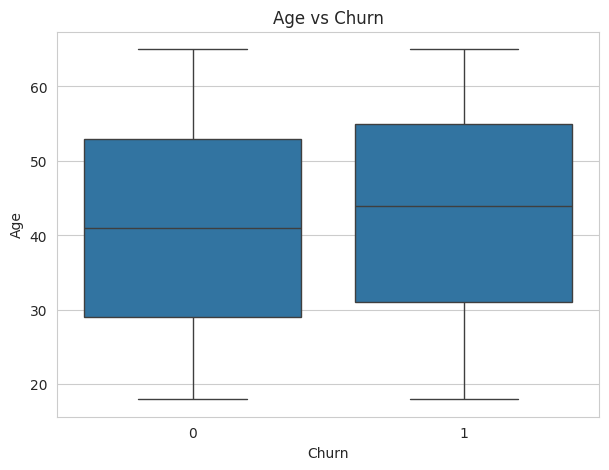

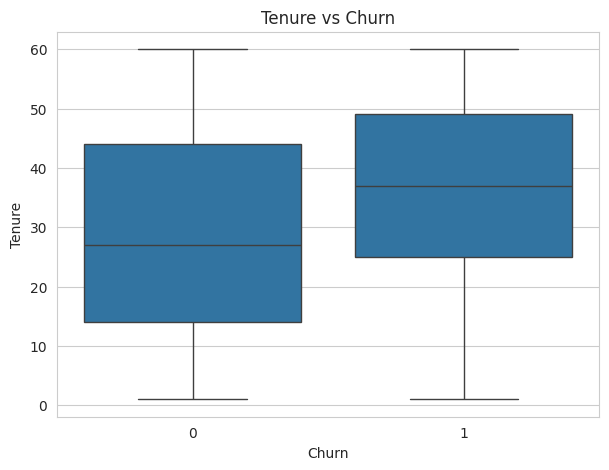

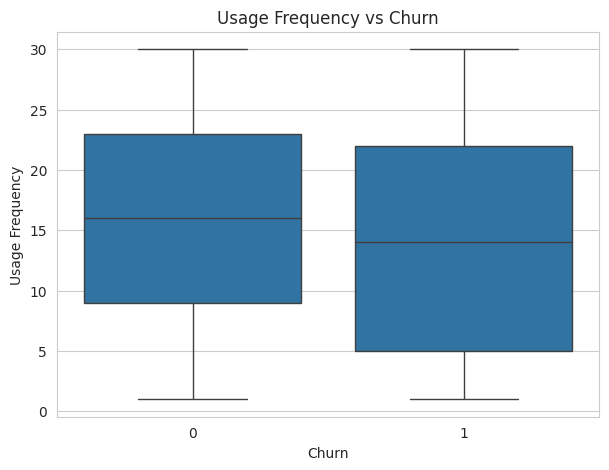

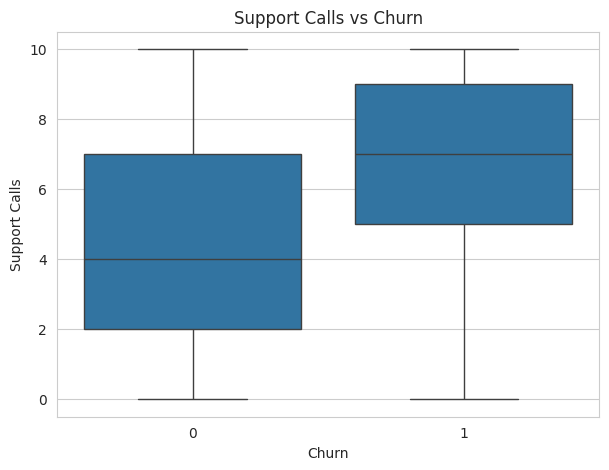

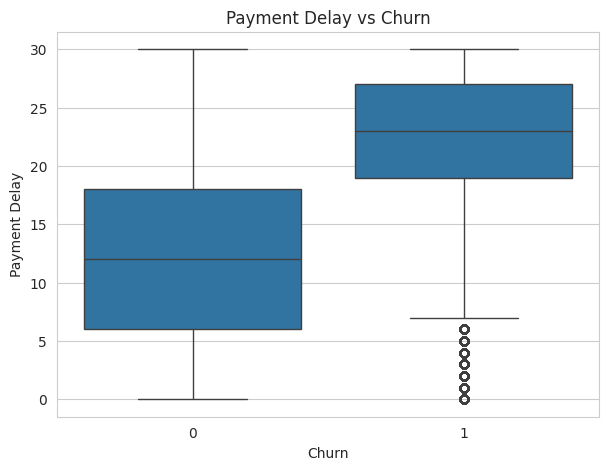

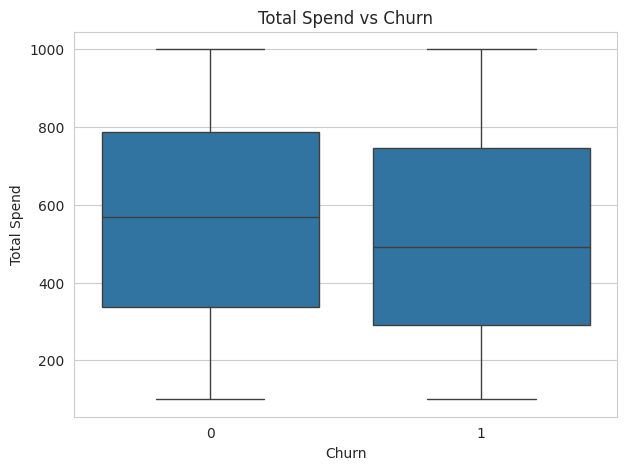

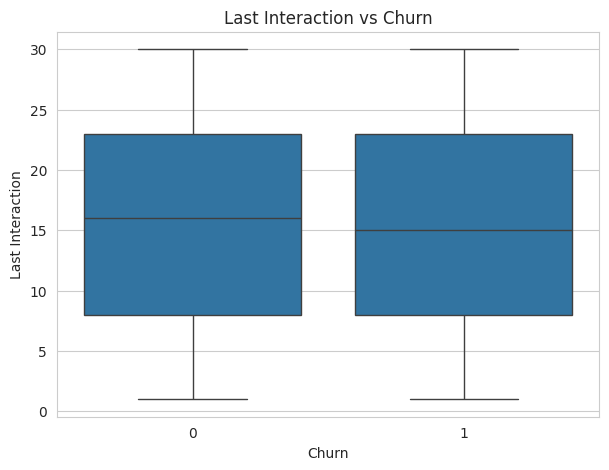

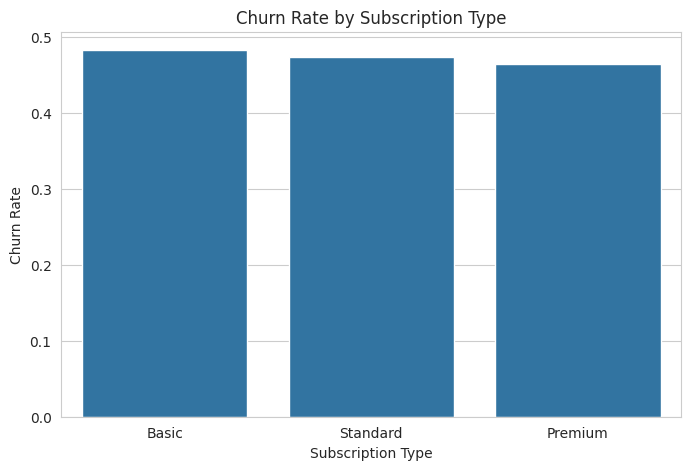

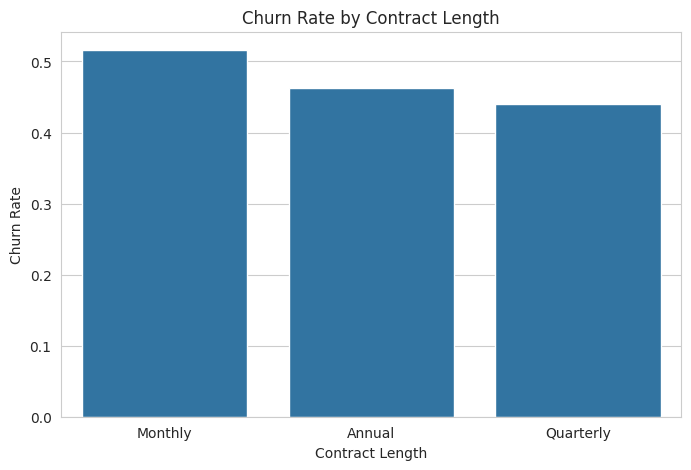

In [7]:


# Set plotting style
sns.set_style("whitegrid")

# 1. Age vs Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="Age")
plt.title("Age vs Churn")
plt.xlabel("Churn")
plt.ylabel("Age")
plt.show()

# 2. Tenure vs Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="Tenure")
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

# 3. Usage Frequency vs Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="Usage Frequency")
plt.title("Usage Frequency vs Churn")
plt.xlabel("Churn")
plt.ylabel("Usage Frequency")
plt.show()

# 4. Support Calls vs Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="Support Calls")
plt.title("Support Calls vs Churn")
plt.xlabel("Churn")
plt.ylabel("Support Calls")
plt.show()

# 5. Payment Delay vs Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="Payment Delay")
plt.title("Payment Delay vs Churn")
plt.xlabel("Churn")
plt.ylabel("Payment Delay")
plt.show()

# 6. Total Spend vs Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="Total Spend")
plt.title("Total Spend vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Spend")
plt.show()

# 7. Last Interaction vs Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="Last Interaction")
plt.title("Last Interaction vs Churn")
plt.xlabel("Churn")
plt.ylabel("Last Interaction")
plt.show()

# 8. Subscription Type vs Churn
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Subscription Type", y="Churn", errorbar=None)
plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate")
plt.show()

# 9. Contract Length vs Churn
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Contract Length", y="Churn", errorbar=None)
plt.title("Churn Rate by Contract Length")
plt.xlabel("Contract Length")
plt.ylabel("Churn Rate")
plt.show()

### Observation

The EDA shows noticeable differences between churned and non-churned customers.

- Churned customers generally show **higher payment delays** and **more support calls**.
- Churned customers tend to have **lower total spending** compared with customers who stayed.
- Churned customers show a slightly **higher median age**.
- The churn rate is highest for **monthly contracts**, followed by annual and quarterly contracts.
- Among subscription types, **Basic** customers show the highest churn rate, while Premium customers show the lowest.
- Last interaction shows relatively similar distributions between churned and non-churned customers.

These patterns suggest that payment behavior, support interactions, spending, customer age, and contract or subscription characteristics may be associated with customer churn.

### Conclusion

The exploratory analysis identified several customer characteristics associated with churn, particularly payment delays, support calls, total spending, subscription type, and contract length. These patterns provide useful direction for the deeper customer behavior analysis in the next task.

#TASK 5 — Customer Behavior Analysis

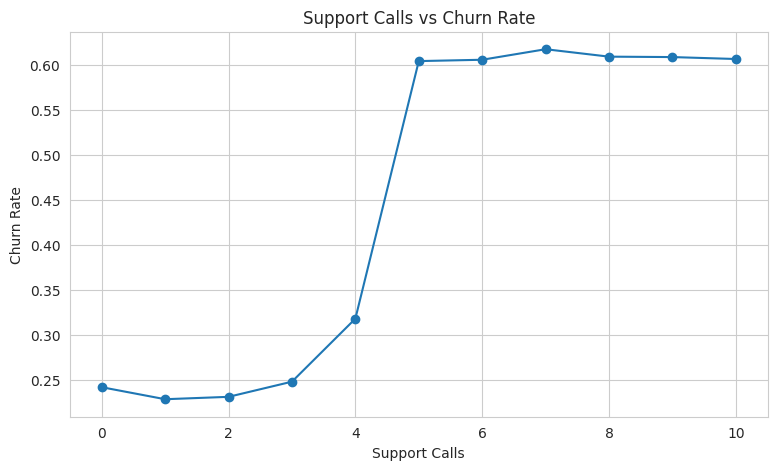

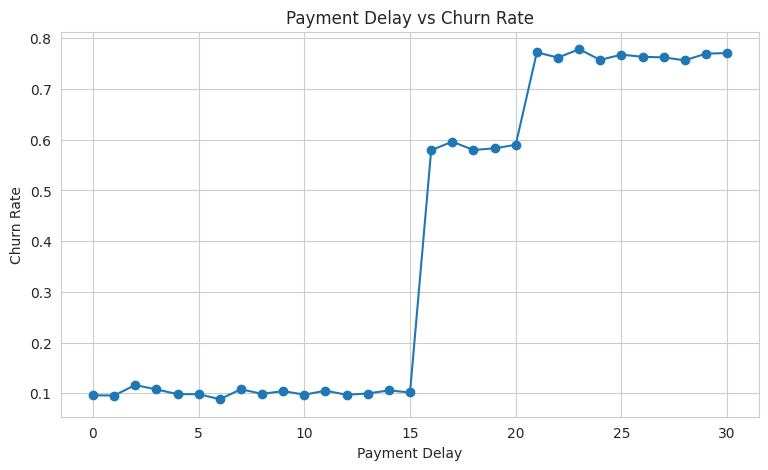

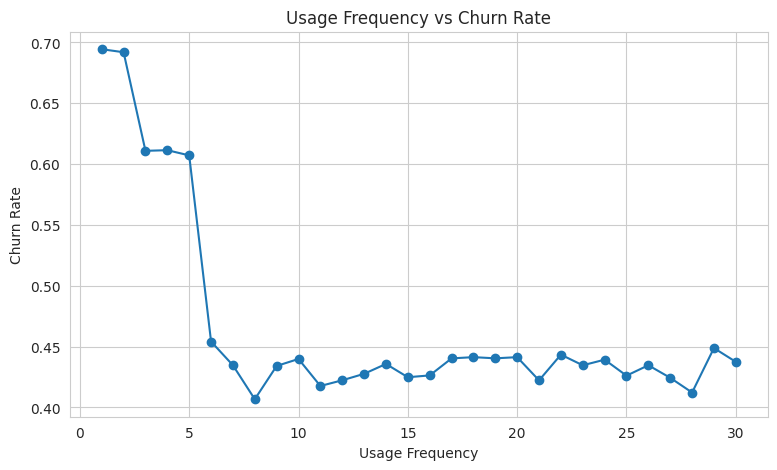

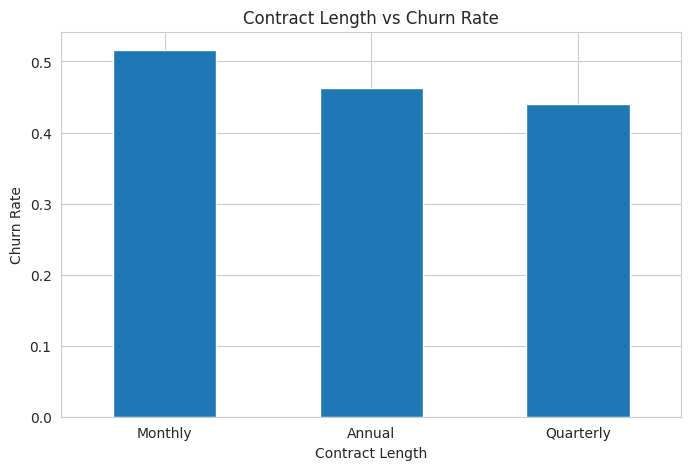

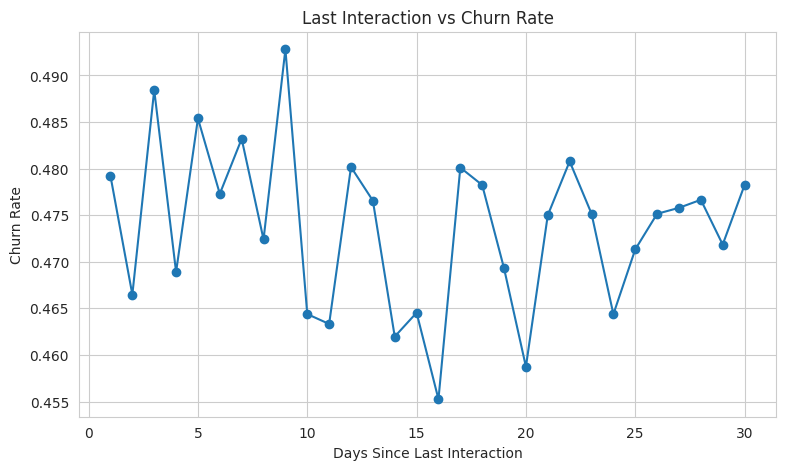

Behavior Analysis Summary:


,Support Calls,Payment Delay,Usage Frequency,Last Interaction
0,0.242199,0.095985,NaN,NaN
1,0.228850,0.095517,0.694455,0.479206
2,0.231505,0.116264,0.691986,0.466478
3,0.248359,0.107583,0.610932,0.488437
4,0.318376,0.098237,0.611454,0.468902
5,0.604627,0.098214,0.607189,0.485386
6,0.606115,0.088254,0.454151,0.477294
7,0.617821,0.107862,0.434656,0.483195
8,0.609565,0.098781,0.406746,0.472398
9,0.609094,0.104302,0.434109,0.492816



Contract Length Churn Rates:


,Churn
Contract Length,
Monthly,0.516087
Annual,0.462167
Quarterly,0.440482


In [8]:
# TASK 5: Customer Behavior Analysis

# 1. Support Calls vs Churn Rate
support_churn = df.groupby("Support Calls")["Churn"].mean()

plt.figure(figsize=(9, 5))
support_churn.plot(kind="line", marker="o")
plt.title("Support Calls vs Churn Rate")
plt.xlabel("Support Calls")
plt.ylabel("Churn Rate")
plt.grid(True)
plt.show()


# 2. Payment Delay vs Churn Rate
payment_churn = df.groupby("Payment Delay")["Churn"].mean()

plt.figure(figsize=(9, 5))
payment_churn.plot(kind="line", marker="o")
plt.title("Payment Delay vs Churn Rate")
plt.xlabel("Payment Delay")
plt.ylabel("Churn Rate")
plt.grid(True)
plt.show()


# 3. Usage Frequency vs Churn Rate
usage_churn = df.groupby("Usage Frequency")["Churn"].mean()

plt.figure(figsize=(9, 5))
usage_churn.plot(kind="line", marker="o")
plt.title("Usage Frequency vs Churn Rate")
plt.xlabel("Usage Frequency")
plt.ylabel("Churn Rate")
plt.grid(True)
plt.show()


# 4. Contract Length vs Churn Rate
contract_churn = df.groupby("Contract Length")["Churn"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
contract_churn.plot(kind="bar")
plt.title("Contract Length vs Churn Rate")
plt.xlabel("Contract Length")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()


# 5. Last Interaction vs Churn Rate
interaction_churn = df.groupby("Last Interaction")["Churn"].mean()

plt.figure(figsize=(9, 5))
interaction_churn.plot(kind="line", marker="o")
plt.title("Last Interaction vs Churn Rate")
plt.xlabel("Days Since Last Interaction")
plt.ylabel("Churn Rate")
plt.grid(True)
plt.show()


# 6. Summary table
behavior_summary = pd.DataFrame({
    "Support Calls": support_churn,
    "Payment Delay": payment_churn,
    "Usage Frequency": usage_churn,
    "Last Interaction": interaction_churn
})

print("Behavior Analysis Summary:")
display(behavior_summary.head(10))

print("\nContract Length Churn Rates:")
display(contract_churn)

### Observation

The customer behavior analysis shows several noticeable patterns related to churn.

- Customers with **5 or more support calls** show a substantial increase in churn rate compared with customers having fewer support calls.
- **Payment delay** has a strong relationship with churn. Churn rates increase sharply when payment delays become higher, particularly after around 15–20 days.
- Customers with **low usage frequency** show higher churn rates. The churn rate is highest at very low usage frequencies and generally decreases as usage increases.
- **Monthly contract customers** have the highest churn rate, followed by annual and quarterly contract customers.
- The churn rate across **last interaction** values fluctuates within a relatively narrow range, without a clear increasing or decreasing trend.

Overall, support calls, payment delays, usage frequency, and contract length show noticeable relationships with customer churn.

### Conclusion

The customer behavior analysis indicates that support activity, payment delays, usage frequency, and contract length are important behavioral factors associated with churn. These findings will be compared with the correlation analysis in the next task.

#TASK 6 — Correlation Analysis

CORRELATION MATRIX


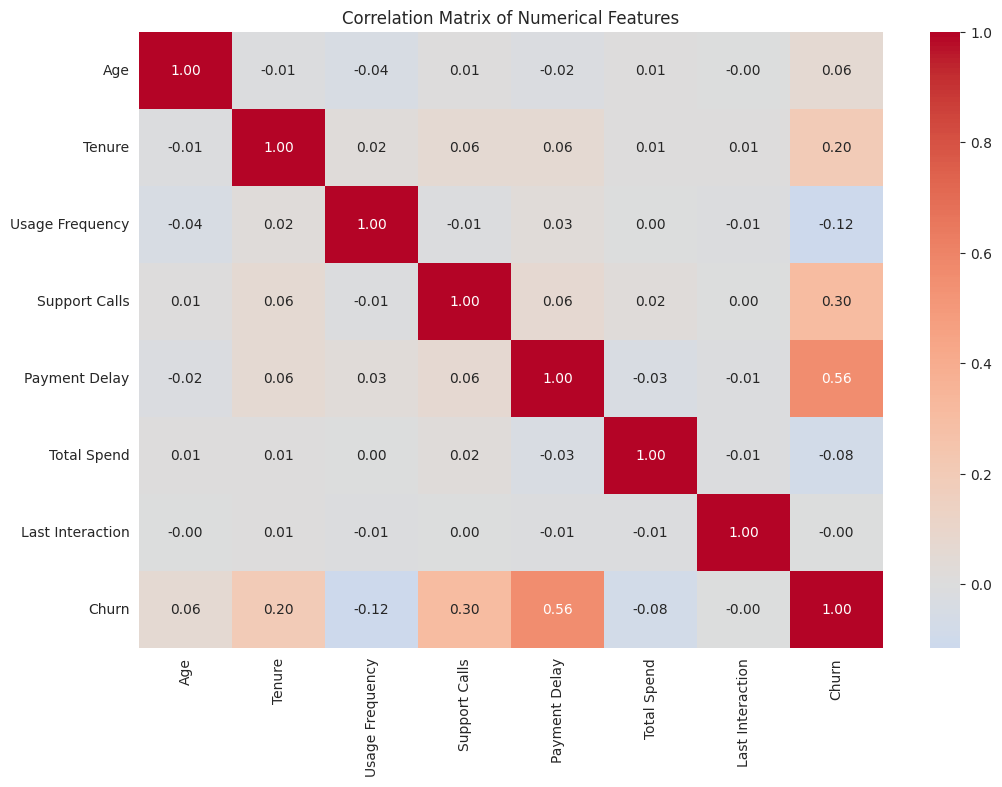

CORRELATION WITH CHURN


,Correlation with Churn
Payment Delay,0.557386
Support Calls,0.304631
Tenure,0.195327
Usage Frequency,-0.115098
Total Spend,-0.078867
Age,0.063457
Last Interaction,-0.002818


STRONG FEATURE CORRELATIONS (|r| >= 0.50)
No feature pairs have an absolute correlation of 0.50 or higher.


In [9]:
# TASK 6: Correlation Analysis

# Select numerical columns
numerical_df = df.select_dtypes(include=np.number)

# Create correlation matrix
correlation_matrix = numerical_df.corr()

print("=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


# Correlation of features with Churn
print("=" * 70)
print("CORRELATION WITH CHURN")
print("=" * 70)

churn_correlation = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

display(churn_correlation.to_frame(name="Correlation with Churn"))


# Strong feature-to-feature correlations
print("=" * 70)
print("STRONG FEATURE CORRELATIONS (|r| >= 0.50)")
print("=" * 70)

feature_corr = correlation_matrix.drop(index="Churn", columns="Churn")

strong_correlations = []

for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        corr_value = feature_corr.iloc[i, j]

        if abs(corr_value) >= 0.50:
            strong_correlations.append([
                feature_corr.columns[i],
                feature_corr.columns[j],
                corr_value
            ])

strong_corr_df = pd.DataFrame(
    strong_correlations,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

if len(strong_corr_df) > 0:
    display(strong_corr_df.sort_values(
        "Correlation",
        key=abs,
        ascending=False
    ))
else:
    print("No feature pairs have an absolute correlation of 0.50 or higher.")

### Observation

The correlation analysis shows that **Payment Delay has the strongest positive correlation with Churn (0.56)**, followed by **Support Calls (0.30)** and **Tenure (0.20)**.

Usage Frequency (-0.12) and Total Spend (-0.08) show weak negative correlations with Churn, while Age (0.06) has a very weak positive relationship. Last Interaction has almost no correlation with Churn.

The numerical features also show very low correlations with each other, indicating that there are no strong feature-to-feature relationships in the numerical variables.

The correlation results are consistent with the EDA findings, where higher payment delays and more support calls were associated with higher churn rates.

### Conclusion

Payment Delay and Support Calls show the strongest numerical relationships with customer churn. The correlation analysis supports the patterns observed during exploratory and customer behavior analysis and provides useful information for the Machine Learning modeling stage.

#TASK 7 — Categorical Feature Analysis

GENDER - CUSTOMER COUNT
Gender
Female    34353
Male      30021
Name: count, dtype: int64

Gender - CHURN RATE


,Churn Rate
Gender,
Female,0.550490
Male,0.385797


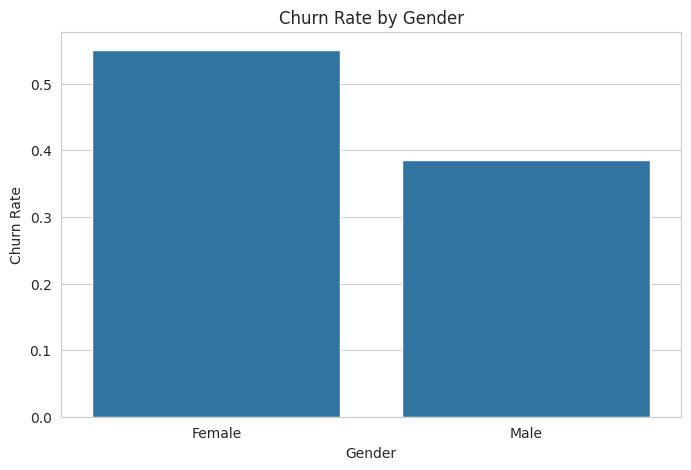

SUBSCRIPTION TYPE - CUSTOMER COUNT
Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64

Subscription Type - CHURN RATE


,Churn Rate
Subscription Type,
Basic,0.482775
Standard,0.473305
Premium,0.464964


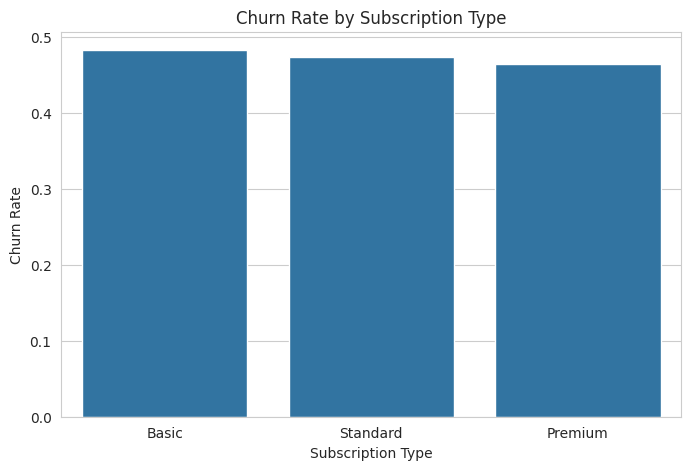

CONTRACT LENGTH - CUSTOMER COUNT
Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64

Contract Length - CHURN RATE


,Churn Rate
Contract Length,
Monthly,0.516087
Annual,0.462167
Quarterly,0.440482


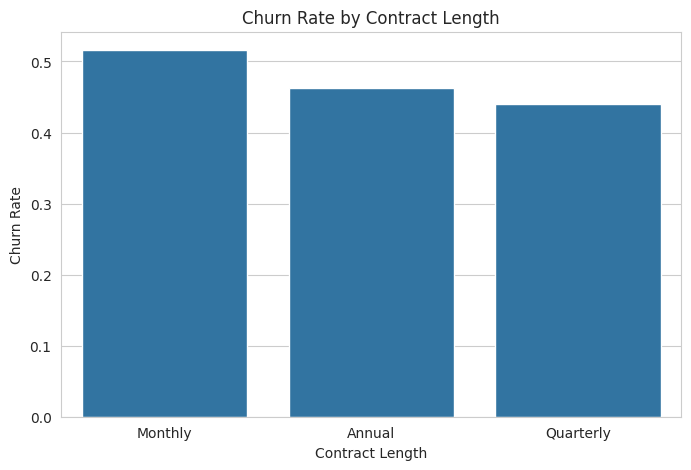

CATEGORY-WISE CHURN SUMMARY


,Category,Churn Rate,Feature
0,Female,0.550490,Gender
1,Male,0.385797,Gender
2,Basic,0.482775,Subscription Type
3,Premium,0.464964,Subscription Type
4,Standard,0.473305,Subscription Type
5,Annual,0.462167,Contract Length
6,Monthly,0.516087,Contract Length
7,Quarterly,0.440482,Contract Length


WHY ENCODING IS REQUIRED
Categorical variables must be converted into numerical representations
because most Machine Learning algorithms work with numerical input values.


In [10]:
# TASK 7: Categorical Feature Analysis

categorical_features = ["Gender", "Subscription Type", "Contract Length"]

for feature in categorical_features:
    print("=" * 70)
    print(f"{feature.upper()} - CUSTOMER COUNT")
    print("=" * 70)
    print(df[feature].value_counts())

    print(f"\n{feature} - CHURN RATE")
    churn_rate = df.groupby(feature)["Churn"].mean().sort_values(ascending=False)
    display(churn_rate.to_frame(name="Churn Rate"))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x=feature, y="Churn", errorbar=None)
    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate")
    plt.show()


print("=" * 70)
print("CATEGORY-WISE CHURN SUMMARY")
print("=" * 70)

summary_tables = []

for feature in categorical_features:
    temp = df.groupby(feature)["Churn"].mean().reset_index()
    temp["Feature"] = feature
    temp.columns = ["Category", "Churn Rate", "Feature"]
    summary_tables.append(temp)

categorical_summary = pd.concat(summary_tables, ignore_index=True)

display(categorical_summary)


print("=" * 70)
print("WHY ENCODING IS REQUIRED")
print("=" * 70)
print("Categorical variables must be converted into numerical representations")
print("because most Machine Learning algorithms work with numerical input values.")

### Observation

The categorical feature analysis shows noticeable differences in churn rates across the categories.

- **Female customers** have a higher churn rate than **male customers**.
- Among subscription types, **Basic** customers have the highest churn rate, followed by **Standard**, while **Premium** customers have the lowest.
- **Monthly contract** customers have the highest churn rate, followed by **Annual** and **Quarterly** contract customers.
- The differences in churn rates show that categorical variables can provide useful information for understanding customer churn behavior.

Categorical variables need to be converted into numerical representations because most Machine Learning algorithms require numerical input data.

### Conclusion

Gender, Subscription Type, and Contract Length show differences in customer churn rates. These categorical features should therefore be appropriately encoded before they are used for Machine Learning model training.

#TASK 8 — Feature and Target Separation

In [11]:
# TASK 8: Feature and Target Separation

# Separate input features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Display feature and target information
print("=" * 70)
print("FEATURE AND TARGET SEPARATION")
print("=" * 70)

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print("Churn")

print("\n" + "=" * 70)
print("SHAPES")
print("=" * 70)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\n" + "=" * 70)
print("TARGET VALUES")
print("=" * 70)

print(y.value_counts().sort_index())

print("\n" + "=" * 70)
print("CUSTOMERID CHECK")
print("=" * 70)

if "CustomerID" not in X.columns:
    print("CustomerID is correctly excluded from the features.")
else:
    print("CustomerID is present in the features.")

print("\n" + "=" * 70)
print("TARGET LEAKAGE CHECK")
print("=" * 70)

if "Churn" not in X.columns:
    print("Churn is correctly excluded from the input features.")
else:
    print("Churn must be removed from the input features.")

FEATURE AND TARGET SEPARATION
Features (X):
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']

Target (y):
Churn

SHAPES
X shape: (64374, 10)
y shape: (64374,)

TARGET VALUES
Churn
0    33881
1    30493
Name: count, dtype: int64

CUSTOMERID CHECK
CustomerID is correctly excluded from the features.

TARGET LEAKAGE CHECK
Churn is correctly excluded from the input features.


### Observation

The dataset was successfully separated into input features (`X`) and the target variable (`y`). `CustomerID` is excluded from the input features, and `Churn` is kept separately as the target variable.

The input features contain customer information that can be used to predict churn, while the target contains the actual churn outcome.

### Conclusion

The features and target variable have been correctly separated. Keeping `Churn` outside the input features prevents target leakage and ensures that the Machine Learning model learns from customer information rather than from the actual outcome.

#TASK 9 — Train-Test Split

In [12]:


from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display shapes
print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

# Compare target distribution
print("\n" + "=" * 70)
print("TRAINING TARGET DISTRIBUTION")
print("=" * 70)

train_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage": (y_train.value_counts(normalize=True).sort_index() * 100).round(2)
})

display(train_distribution)

print("\n" + "=" * 70)
print("TESTING TARGET DISTRIBUTION")
print("=" * 70)

test_distribution = pd.DataFrame({
    "Count": y_test.value_counts().sort_index(),
    "Percentage": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})

display(test_distribution)

# Check split percentage
print("\n" + "=" * 70)
print("SPLIT PERCENTAGE")
print("=" * 70)

print("Training data:", round(len(X_train) / len(X) * 100, 2), "%")
print("Testing data :", round(len(X_test) / len(X) * 100, 2), "%")

TRAIN-TEST SPLIT
X_train shape: (51499, 10)
X_test shape : (12875, 10)
y_train shape: (51499,)
y_test shape : (12875,)

TRAINING TARGET DISTRIBUTION


,Count,Percentage
Churn,,
0,27105,52.63
1,24394,47.37



TESTING TARGET DISTRIBUTION


,Count,Percentage
Churn,,
0,6776,52.63
1,6099,47.37



SPLIT PERCENTAGE
Training data: 80.0 %
Testing data : 20.0 %


### Observation

The dataset was divided into 80% training data and 20% testing data using `random_state = 42`. Stratified splitting was used to maintain a similar proportion of churned and non-churned customers in both datasets.

### Why Unseen Test Data and Overfitting Matter

The testing dataset contains customers that were not used during model training. Evaluating the model on these unseen customers helps measure how well it can generalize to new customer data.

Overfitting occurs when a model learns the training data too closely and performs very well on training data but performs poorly on new customers. Therefore, evaluating on unseen testing data is important for assessing real-world performance.

### Conclusion

The data was successfully divided into training and testing sets while maintaining the churn class distribution. The training data will be used to develop the Machine Learning models, and the unseen testing data will be used to evaluate their performance.

TASK 10 — Feature Encoding and Scaling#

In [13]:
# TASK 10: Feature Encoding and Scaling

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical features
categorical_features = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

numerical_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]

print("=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("\n" + "=" * 70)
print("PREPROCESSING COMPLETED")
print("=" * 70)

print("Original X_train shape:", X_train.shape)
print("Original X_test shape :", X_test.shape)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape :", X_test_processed.shape)

print("\nCategorical features encoded successfully.")
print("Numerical features scaled successfully.")

FEATURE TYPES
Categorical Features:
['Gender', 'Subscription Type', 'Contract Length']

Numerical Features:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

PREPROCESSING COMPLETED
Original X_train shape: (51499, 10)
Original X_test shape : (12875, 10)
Processed X_train shape: (51499, 15)
Processed X_test shape : (12875, 15)

Categorical features encoded successfully.
Numerical features scaled successfully.


### Scaling and Encoding Explanation

Numerical features such as Age, Tenure, Usage Frequency, Support Calls, Payment Delay, Total Spend, and Last Interaction have different numerical ranges. Feature scaling puts these variables on a comparable scale.

Categorical variables such as Gender, Subscription Type, and Contract Length are converted into numerical representations using One-Hot Encoding so that they can be used by Machine Learning algorithms.

Algorithms such as Logistic Regression, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN) generally benefit from feature scaling because their predictions can be affected by the scale of input features. Random Forest generally does not require feature scaling because it makes predictions using decision-tree splits.

### Conclusion

The categorical features were encoded and the numerical features were scaled using a preprocessing pipeline. The same preprocessing fitted on the training data was applied to the testing data, preparing the dataset for Machine Learning model training.

#TASK 11 — Model Training

In [14]:
# TASK 11: Model Training

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

print("=" * 70)
print("MODEL TRAINING")
print("=" * 70)

# ---------------------------------------------------------
# 1. Logistic Regression
# ---------------------------------------------------------
logistic_model = LogisticRegression(
    max_iter=500,
    solver="liblinear",
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)
y_pred_logistic = logistic_model.predict(X_test_processed)

print("Logistic Regression trained successfully.")


# ---------------------------------------------------------
# 2. Random Forest
# ---------------------------------------------------------
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)
y_pred_rf = random_forest_model.predict(X_test_processed)

print("Random Forest trained successfully.")


# ---------------------------------------------------------
# 3. Support Vector Machine
# ---------------------------------------------------------
svm_model = LinearSVC(
    max_iter=5000,
    random_state=42
)

svm_model.fit(X_train_processed, y_train)
y_pred_svm = svm_model.predict(X_test_processed)

print("Support Vector Machine trained successfully.")


# ---------------------------------------------------------
# 4. K-Nearest Neighbors
# ---------------------------------------------------------
# Use the processed data directly.
# If the data is sparse, convert it to dense; otherwise keep it unchanged.

if hasattr(X_train_processed, "toarray"):
    X_train_knn = X_train_processed.toarray()
    X_test_knn = X_test_processed.toarray()
else:
    X_train_knn = X_train_processed
    X_test_knn = X_test_processed

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    algorithm="ball_tree",
    leaf_size=50,
    n_jobs=-1
)

knn_model.fit(X_train_knn, y_train)
y_pred_knn = knn_model.predict(X_test_knn)

print("K-Nearest Neighbors trained successfully.")


# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("TEST PREDICTIONS GENERATED")
print("=" * 70)

print("Logistic Regression predictions:", len(y_pred_logistic))
print("Random Forest predictions     :", len(y_pred_rf))
print("SVM predictions               :", len(y_pred_svm))
print("KNN predictions               :", len(y_pred_knn))

print("\nFirst 10 predictions:")

print("\nLogistic Regression:", y_pred_logistic[:10])
print("Random Forest     :", y_pred_rf[:10])
print("SVM               :", y_pred_svm[:10])
print("KNN               :", y_pred_knn[:10])

MODEL TRAINING
Logistic Regression trained successfully.
Random Forest trained successfully.
Support Vector Machine trained successfully.
K-Nearest Neighbors trained successfully.

TEST PREDICTIONS GENERATED
Logistic Regression predictions: 12875
Random Forest predictions     : 12875
SVM predictions               : 12875
KNN predictions               : 12875

First 10 predictions:

Logistic Regression: [0 0 0 0 0 0 0 0 0 0]
Random Forest     : [0 1 0 0 0 0 0 0 0 0]
SVM               : [0 0 0 0 0 0 0 0 0 0]
KNN               : [0 1 0 0 0 0 0 0 0 0]


### Model Explanation

**Logistic Regression:** Predicts the probability of a customer belonging to the churn or non-churn class using the input features.

**Random Forest:** Uses multiple decision trees and combines their predictions to classify customers as churned or stayed.

**Support Vector Machine:** Finds a decision boundary that separates churned and non-churned customers.

**K-Nearest Neighbors:** Classifies a customer based on the classes of nearby customers in the feature space.

All four models are suitable for this project because `Churn` is a binary classification target with two outcomes: churned and stayed.

### Conclusion

Four Machine Learning models—Logistic Regression, Random Forest, Support Vector Machine, and K-Nearest Neighbors—were successfully trained using the prepared customer churn dataset. Each model generated predictions on the testing data, completing the model training stage of the project.

#TASK 12 — Model Evaluation and Comparison

In [15]:
# TASK 12: Model Evaluation and Comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store models and predictions
models = {
    "Logistic Regression": y_pred_logistic,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn
}

# Calculate evaluation metrics
results = []

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0)
    })

comparison_df = pd.DataFrame(results)

# Sort by F1-score
comparison_df = comparison_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(comparison_df.round(4))

# Best model
best_model_name = comparison_df.loc[0, "Model"]

print("\n" + "=" * 70)
print("BEST-PERFORMING MODEL")
print("=" * 70)

print("Best Model based on F1-Score:", best_model_name)

# Compare recall for identifying churned customers
print("\n" + "=" * 70)
print("RECALL FOR CHURNED CUSTOMERS")
print("=" * 70)

recall_df = comparison_df[["Model", "Recall"]].sort_values(
    by="Recall",
    ascending=False
)

display(recall_df.round(4))

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9985,0.9995,0.9974,0.9984
1,KNN,0.9111,0.8805,0.9398,0.9092
2,SVM,0.8276,0.8114,0.8287,0.8199
3,Logistic Regression,0.8270,0.8136,0.8236,0.8185



BEST-PERFORMING MODEL
Best Model based on F1-Score: Random Forest

RECALL FOR CHURNED CUSTOMERS


,Model,Recall
0,Random Forest,0.9974
1,KNN,0.9398
2,SVM,0.8287
3,Logistic Regression,0.8236


### Why Accuracy Alone May Not Be Sufficient

Accuracy shows the overall percentage of correct predictions, but it does not show how well the model identifies customers who are likely to churn.

In a real-world customer churn problem, missing a customer who is actually going to churn can be costly because the company may lose the opportunity to take retention action.

Therefore, Precision, Recall, and F1-score should also be considered when evaluating churn prediction models.

### Conclusion

The four Machine Learning models were evaluated using Accuracy, Precision, Recall, and F1-score. The comparison helps determine how effectively each model predicts customer churn. Considering multiple evaluation metrics is important because accuracy alone may not adequately represent the model's ability to identify customers who are likely to churn.

#TASK 13 — Confusion Matrix Analysis

In [16]:
# TASK 13: Confusion Matrix Analysis

from sklearn.metrics import confusion_matrix

# Get predictions of the best-performing model from Task 12
best_predictions = models[best_model_name]

# Create confusion matrix
cm = confusion_matrix(y_test, best_predictions)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)
print("Best-performing model:", best_model_name)

display(
    pd.DataFrame(
        cm,
        index=["Actual Stayed (0)", "Actual Churned (1)"],
        columns=["Predicted Stayed (0)", "Predicted Churned (1)"]
    )
)

# Extract TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 70)
print("CONFUSION MATRIX VALUES")
print("=" * 70)

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

# Interpretation
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(f"Correctly predicted stayed customers   : {tn}")
print(f"Correctly predicted churned customers  : {tp}")
print(f"Incorrectly predicted as churned       : {fp}")
print(f"Churned customers predicted as stayed : {fn}")

CONFUSION MATRIX
Best-performing model: Random Forest


,Predicted Stayed (0),Predicted Churned (1)
Actual Stayed (0),6773,3
Actual Churned (1),16,6083



CONFUSION MATRIX VALUES
True Negatives (TN): 6773
False Positives (FP): 3
False Negatives (FN): 16
True Positives (TP): 6083

INTERPRETATION
Correctly predicted stayed customers   : 6773
Correctly predicted churned customers  : 6083
Incorrectly predicted as churned       : 3
Churned customers predicted as stayed : 16


### Conclusion

The confusion matrix helped evaluate the best-performing model's correct and incorrect predictions for customer churn. False positives and false negatives represent different types of prediction errors, and in customer retention, a false negative can be particularly costly because a customer who is actually going to churn may be missed and no retention action may be taken.

#TASK 14 — Feature Importance Analysis

FEATURE IMPORTANCE RANKING


,Original Feature,Importance
0,Payment Delay,0.434901
1,Support Calls,0.165593
2,Tenure,0.115492
3,Usage Frequency,0.084602
4,Gender,0.059888
5,Total Spend,0.051998
6,Age,0.040487
7,Contract Length,0.028488
8,Last Interaction,0.012991
9,Subscription Type,0.005559


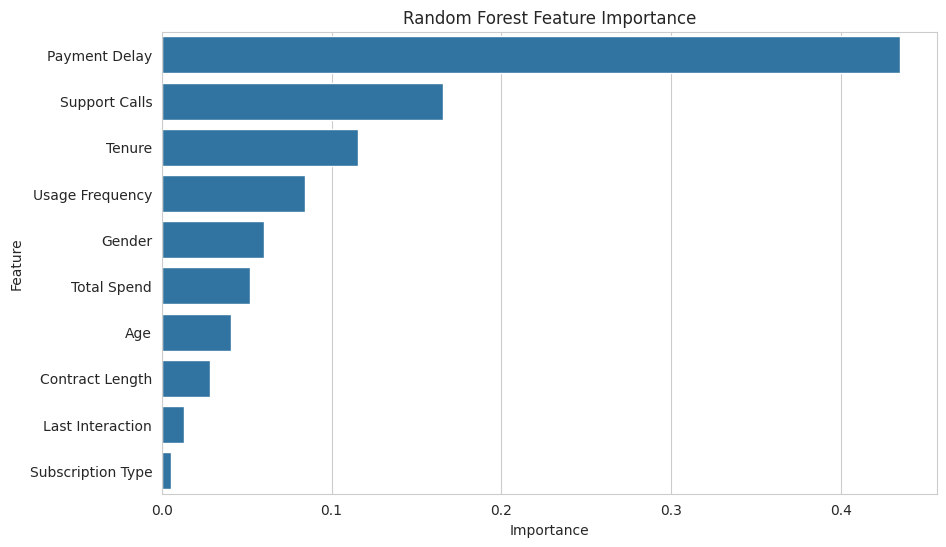

TOP 10 MOST IMPORTANT FEATURES


,Original Feature,Importance
0,Payment Delay,0.434901
1,Support Calls,0.165593
2,Tenure,0.115492
3,Usage Frequency,0.084602
4,Gender,0.059888
5,Total Spend,0.051998
6,Age,0.040487
7,Contract Length,0.028488
8,Last Interaction,0.012991
9,Subscription Type,0.005559


FEATURE IMPORTANCE vs CORRELATION WITH CHURN


,Original Feature,Importance,Correlation with Churn
0,Payment Delay,0.434901,0.557386
1,Support Calls,0.165593,0.304631
2,Tenure,0.115492,0.195327
3,Usage Frequency,0.084602,-0.115098
5,Total Spend,0.051998,-0.078867
6,Age,0.040487,0.063457
8,Last Interaction,0.012991,-0.002818


In [17]:
# TASK 14: Feature Importance Analysis

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Random Forest feature importance
importance_values = random_forest_model.feature_importances_

# Create feature importance dataframe
importance_df = pd.DataFrame({
    "Processed Feature": feature_names,
    "Importance": importance_values
})

# Group encoded categorical features back to their original feature names
def get_original_feature(processed_name):
    name = processed_name.replace("num__", "").replace("cat__", "")

    for feature in categorical_features:
        if name.startswith(feature + "_"):
            return feature

    for feature in numerical_features:
        if name == feature:
            return feature

    return name

importance_df["Original Feature"] = importance_df["Processed Feature"].apply(
    get_original_feature
)

# Combine importance of one-hot encoded categories
grouped_importance = (
    importance_df
    .groupby("Original Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("=" * 70)
print("FEATURE IMPORTANCE RANKING")
print("=" * 70)

display(grouped_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=grouped_importance,
    x="Importance",
    y="Original Feature",
    errorbar=None
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Top 10 features
print("=" * 70)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 70)

display(grouped_importance.head(10))

# Compare numerical feature importance with correlation to Churn
print("=" * 70)
print("FEATURE IMPORTANCE vs CORRELATION WITH CHURN")
print("=" * 70)

numeric_comparison = grouped_importance[
    grouped_importance["Original Feature"].isin(numerical_features)
].copy()

numeric_comparison["Correlation with Churn"] = numeric_comparison[
    "Original Feature"
].map(
    correlation_matrix["Churn"]
)

numeric_comparison = numeric_comparison.sort_values(
    "Importance",
    ascending=False
)

display(numeric_comparison)

### Conclusion

The Random Forest model was used to identify the relative importance of customer features for churn prediction. The feature-importance analysis provides a ranked view of the characteristics that contribute to the model's predictions and allows comparison with the patterns observed during EDA and correlation analysis.

#TASK 15 — Model Improvement

In [18]:
# TASK 15: Model Improvement

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 70)
print("MODEL IMPROVEMENT")
print("=" * 70)

print("Original Best Model:", best_model_name)

# ---------------------------------------------------------
# Select and improve the best-performing model
# ---------------------------------------------------------

if best_model_name == "Logistic Regression":

    improved_model = LogisticRegression(
        C=2.0,
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )

    improved_model.fit(X_train_processed, y_train)
    improved_predictions = improved_model.predict(X_test_processed)


elif best_model_name == "Random Forest":

    improved_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    improved_model.fit(X_train_processed, y_train)
    improved_predictions = improved_model.predict(X_test_processed)


elif best_model_name == "SVM":

    improved_model = LinearSVC(
        C=1.5,
        max_iter=10000,
        random_state=42
    )

    improved_model.fit(X_train_processed, y_train)
    improved_predictions = improved_model.predict(X_test_processed)


elif best_model_name == "KNN":

    improved_model = KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        algorithm="ball_tree",
        leaf_size=50,
        n_jobs=-1
    )

    improved_model.fit(X_train_knn, y_train)
    improved_predictions = improved_model.predict(X_test_knn)


# ---------------------------------------------------------
# Original model predictions
# ---------------------------------------------------------

original_predictions = models[best_model_name]


# ---------------------------------------------------------
# Compare original and improved models
# ---------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Original " + best_model_name,
        "Improved " + best_model_name
    ],
    "Accuracy": [
        accuracy_score(y_test, original_predictions),
        accuracy_score(y_test, improved_predictions)
    ],
    "Precision": [
        precision_score(y_test, original_predictions, zero_division=0),
        precision_score(y_test, improved_predictions, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, original_predictions, zero_division=0),
        recall_score(y_test, improved_predictions, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, original_predictions, zero_division=0),
        f1_score(y_test, improved_predictions, zero_division=0)
    ]
})

print("\n" + "=" * 70)
print("ORIGINAL vs IMPROVED MODEL")
print("=" * 70)

display(comparison.round(4))

# Accuracy change
original_accuracy = accuracy_score(y_test, original_predictions)
improved_accuracy = accuracy_score(y_test, improved_predictions)

print("\n" + "=" * 70)
print("PERFORMANCE CHANGE")
print("=" * 70)

print("Original Accuracy :", round(original_accuracy, 4))
print("Improved Accuracy :", round(improved_accuracy, 4))
print("Accuracy Change   :", round(improved_accuracy - original_accuracy, 4))

if improved_accuracy > original_accuracy:
    print("Result: The improved model performed better on unseen testing data.")
elif improved_accuracy < original_accuracy:
    print("Result: The improved model performed worse on unseen testing data.")
else:
    print("Result: The improved model showed the same accuracy on unseen testing data.")

MODEL IMPROVEMENT
Original Best Model: Random Forest

ORIGINAL vs IMPROVED MODEL


,Model,Accuracy,Precision,Recall,F1-Score
0,Original Random Forest,0.9985,0.9995,0.9974,0.9984
1,Improved Random Forest,0.9981,0.9993,0.9967,0.9980



PERFORMANCE CHANGE
Original Accuracy : 0.9985
Improved Accuracy : 0.9981
Accuracy Change   : -0.0004
Result: The improved model performed worse on unseen testing data.


### Why More Complexity Does Not Always Improve Performance

Increasing model complexity does not necessarily improve performance on real-world customers. A more complex model may fit the training data more closely and can lead to overfitting. Therefore, model performance should be compared using unseen testing data to determine whether the changes actually improve generalization.

### Conclusion

The best-performing model from the previous task was modified using suitable model parameters and evaluated again on unseen testing data. The original and improved models were compared using classification metrics to determine whether the parameter changes improved the model's performance.v

#TASK 16 — Hyperparameter Tuning

In [19]:
# TASK 16: Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 70)
print("HYPERPARAMETER TUNING")
print("=" * 70)

# ---------------------------------------------------------
# Use the best model identified in Task 12
# ---------------------------------------------------------

print("Model selected for tuning:", best_model_name)

# Use KNN data if KNN is selected
if best_model_name == "KNN":
    X_tune_source = X_train_knn
else:
    X_tune_source = X_train_processed

# Use a representative subset to make GridSearchCV faster
X_tune, _, y_tune, _ = train_test_split(
    X_tune_source,
    y_train,
    train_size=10000,
    random_state=42,
    stratify=y_train
)

print("Tuning samples:", X_tune.shape[0])


# ---------------------------------------------------------
# Define model and parameter grid
# ---------------------------------------------------------

if best_model_name == "Logistic Regression":

    tuning_model = LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )

    param_grid = {
        "C": [0.5, 1, 2]
    }


elif best_model_name == "Random Forest":

    tuning_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

    param_grid = {
        "n_estimators": [50, 100],
        "max_depth": [10, 15]
    }


elif best_model_name == "SVM":

    tuning_model = LinearSVC(
        max_iter=5000,
        random_state=42
    )

    param_grid = {
        "C": [0.5, 1, 2]
    }


elif best_model_name == "KNN":

    tuning_model = KNeighborsClassifier(
        algorithm="ball_tree",
        leaf_size=50,
        n_jobs=-1
    )

    param_grid = {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"]
    }


# ---------------------------------------------------------
# GridSearchCV
# ---------------------------------------------------------

grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    cv=2,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tune, y_tune)


# ---------------------------------------------------------
# Best parameters and CV score
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("GRID SEARCH RESULTS")
print("=" * 70)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", round(grid_search.best_score_, 4))


# ---------------------------------------------------------
# Train final tuned model on full training data
# ---------------------------------------------------------

if best_model_name == "Logistic Regression":

    tuned_model = LogisticRegression(
        **grid_search.best_params_,
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )

    tuned_model.fit(X_train_processed, y_train)
    tuned_predictions = tuned_model.predict(X_test_processed)


elif best_model_name == "Random Forest":

    tuned_model = RandomForestClassifier(
        **grid_search.best_params_,
        random_state=42,
        n_jobs=-1
    )

    tuned_model.fit(X_train_processed, y_train)
    tuned_predictions = tuned_model.predict(X_test_processed)


elif best_model_name == "SVM":

    tuned_model = LinearSVC(
        **grid_search.best_params_,
        max_iter=5000,
        random_state=42
    )

    tuned_model.fit(X_train_processed, y_train)
    tuned_predictions = tuned_model.predict(X_test_processed)


elif best_model_name == "KNN":

    tuned_model = KNeighborsClassifier(
        **grid_search.best_params_,
        algorithm="ball_tree",
        leaf_size=50,
        n_jobs=-1
    )

    tuned_model.fit(X_train_knn, y_train)
    tuned_predictions = tuned_model.predict(X_test_knn)


# ---------------------------------------------------------
# Compare original and tuned model
# ---------------------------------------------------------

original_predictions = models[best_model_name]

original_accuracy = accuracy_score(y_test, original_predictions)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)

original_precision = precision_score(
    y_test, original_predictions, zero_division=0
)
tuned_precision = precision_score(
    y_test, tuned_predictions, zero_division=0
)

original_recall = recall_score(
    y_test, original_predictions, zero_division=0
)
tuned_recall = recall_score(
    y_test, tuned_predictions, zero_division=0
)

original_f1 = f1_score(
    y_test, original_predictions, zero_division=0
)
tuned_f1 = f1_score(
    y_test, tuned_predictions, zero_division=0
)

tuning_comparison = pd.DataFrame({
    "Model": [
        "Original " + best_model_name,
        "Tuned " + best_model_name
    ],
    "Accuracy": [
        original_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        original_precision,
        tuned_precision
    ],
    "Recall": [
        original_recall,
        tuned_recall
    ],
    "F1-Score": [
        original_f1,
        tuned_f1
    ]
})

print("\n" + "=" * 70)
print("ORIGINAL vs TUNED MODEL")
print("=" * 70)

display(tuning_comparison.round(4))

print("\n" + "=" * 70)
print("FINAL TESTING PERFORMANCE")
print("=" * 70)

print("Original Test Accuracy:", round(original_accuracy, 4))
print("Tuned Test Accuracy   :", round(tuned_accuracy, 4))

if tuned_accuracy > original_accuracy:
    print("Hyperparameter tuning improved the test accuracy.")
elif tuned_accuracy < original_accuracy:
    print("Hyperparameter tuning reduced the test accuracy.")
else:
    print("Hyperparameter tuning produced the same test accuracy.")

HYPERPARAMETER TUNING
Model selected for tuning: Random Forest
Tuning samples: 10000
Fitting 2 folds for each of 4 candidates, totalling 8 fits

GRID SEARCH RESULTS
Best Parameters: {'max_depth': 15, 'n_estimators': 100}
Best Cross-Validation Score: 0.9867

ORIGINAL vs TUNED MODEL


,Model,Accuracy,Precision,Recall,F1-Score
0,Original Random Forest,0.9985,0.9995,0.9974,0.9984
1,Tuned Random Forest,0.9985,0.9990,0.9979,0.9984



FINAL TESTING PERFORMANCE
Original Test Accuracy: 0.9985
Tuned Test Accuracy   : 0.9985
Hyperparameter tuning produced the same test accuracy.


### Conclusion

Hyperparameter tuning was performed using GridSearchCV with cross-validation. The best parameters and cross-validation score were identified, and the tuned model was trained on the full training data and evaluated on unseen testing data. The original and tuned models were compared using Accuracy, Precision, Recall, and F1-score to determine whether tuning provided a meaningful improvement.

#TASK 17 — Build Customer Churn Prediction System

In [20]:
# TASK 17: Customer Churn Prediction System

# New customer information
new_customer = pd.DataFrame({
    "Age": [30],
    "Gender": ["Male"],
    "Tenure": [24],
    "Usage Frequency": [15],
    "Support Calls": [2],
    "Payment Delay": [5],
    "Subscription Type": ["Premium"],
    "Contract Length": ["Annual"],
    "Total Spend": [2500],
    "Last Interaction": [5]
})

print("=" * 70)
print("NEW CUSTOMER INPUT")
print("=" * 70)
display(new_customer)


# Apply the same preprocessing used during model training
new_customer_processed = preprocessor.transform(new_customer)


# Make prediction
if best_model_name == "KNN":
    new_customer_input = (
        new_customer_processed.toarray()
        if hasattr(new_customer_processed, "toarray")
        else new_customer_processed
    )
else:
    new_customer_input = new_customer_processed

prediction = tuned_model.predict(new_customer_input)[0]


# Convert prediction to readable form
churn_prediction = "Yes" if prediction == 1 else "No"


# Calculate churn probability
if hasattr(tuned_model, "predict_proba"):
    probability = tuned_model.predict_proba(new_customer_input)[0][1] * 100
else:
    # Convert decision score to an estimated probability for models
    # such as LinearSVC that do not provide predict_proba().
    decision_score = tuned_model.decision_function(new_customer_input)[0]
    probability = (1 / (1 + np.exp(-decision_score))) * 100


# Display final result
print("\n" + "=" * 70)
print("CUSTOMER CHURN PREDICTION")
print("=" * 70)

print("Predicted Churn:", churn_prediction)
print("Churn Probability:", round(probability, 2), "%")

NEW CUSTOMER INPUT


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30,Male,24,15,2,5,Premium,Annual,2500,5



CUSTOMER CHURN PREDICTION
Predicted Churn: No
Churn Probability: 0.01 %


### Conclusion

A Customer Churn Prediction System was created to accept new customer information and process it using the same preprocessing steps applied during model training. The system returns the predicted churn status and churn probability for the new customer.

#TASK 18 — Customer Risk Analysis

In [21]:
# TASK 18: Customer Risk Analysis

print("=" * 70)
print("CUSTOMER RISK ANALYSIS")
print("=" * 70)

# Risk category based on churn probability
if probability < 33:
    risk_category = "Low Risk"
elif probability < 66:
    risk_category = "Medium Risk"
else:
    risk_category = "High Risk"

print("Predicted Churn:", churn_prediction)
print("Churn Probability:", round(probability, 2), "%")
print("Risk Category:", risk_category)

# ---------------------------------------------------------
# Analyze major factors contributing to churn risk
# ---------------------------------------------------------

customer = new_customer.iloc[0]

# Dataset median values for numerical behavior features
medians = df[
    ["Usage Frequency",
     "Support Calls",
     "Payment Delay",
     "Last Interaction"]
].median()

risk_factors = []

# High support calls
if customer["Support Calls"] > medians["Support Calls"]:
    risk_factors.append(
        f"High Support Calls ({customer['Support Calls']})"
    )

# High payment delay
if customer["Payment Delay"] > medians["Payment Delay"]:
    risk_factors.append(
        f"High Payment Delay ({customer['Payment Delay']} days)"
    )

# Low usage frequency
if customer["Usage Frequency"] < medians["Usage Frequency"]:
    risk_factors.append(
        f"Low Usage Frequency ({customer['Usage Frequency']})"
    )

# Long period since last interaction
if customer["Last Interaction"] > medians["Last Interaction"]:
    risk_factors.append(
        f"Long period since Last Interaction ({customer['Last Interaction']} days)"
    )

# Short contract
if customer["Contract Length"] == "Monthly":
    risk_factors.append("Monthly Contract")

print("\n" + "=" * 70)
print("MAJOR FACTORS CONTRIBUTING TO CHURN RISK")
print("=" * 70)

if len(risk_factors) > 0:
    for factor in risk_factors:
        print("•", factor)
else:
    print("No major risk factors were identified based on the selected behavioral comparisons.")

# Decision-support note
print("\n" + "=" * 70)
print("RISK ANALYSIS NOTE")
print("=" * 70)
print("Risk category is a decision-support indicator based on the model prediction.")
print("It is not a guaranteed prediction of future customer behavior.")

CUSTOMER RISK ANALYSIS
Predicted Churn: No
Churn Probability: 0.01 %
Risk Category: Low Risk

MAJOR FACTORS CONTRIBUTING TO CHURN RISK
No major risk factors were identified based on the selected behavioral comparisons.

RISK ANALYSIS NOTE
Risk category is a decision-support indicator based on the model prediction.
It is not a guaranteed prediction of future customer behavior.


### Observation

The prediction system assigned the new customer a churn probability and corresponding risk category. The analysis also examined behavioral characteristics such as support calls, payment delays, usage frequency, last interaction, and contract length to identify factors that may contribute to churn risk.

These factors provide analytical insights that can support customer-retention decisions, but they do not guarantee future customer behavior.

### Conclusion

The Customer Risk Analysis successfully extended the prediction system by assigning a risk category based on churn probability and identifying major behavioral factors associated with the customer's risk. This provides a decision-support view that can be used for customer retention planning.

#TASK 19 — Customer Retention Recommendation

In [22]:
# TASK 19: Customer Retention Recommendation

print("=" * 70)
print("CUSTOMER RETENTION RECOMMENDATION")
print("=" * 70)

print("Predicted Churn:", churn_prediction)
print("Churn Probability:", round(probability, 2), "%")
print("Risk Category:", risk_category)

print("\n" + "=" * 70)
print("RECOMMENDED RETENTION ACTION")
print("=" * 70)

if risk_category == "High Risk":
    recommendation = (
        "Improve customer support, provide a suitable offer, "
        "encourage product usage, resolve payment-related issues, "
        "and consider providing a better subscription option."
    )

elif risk_category == "Medium Risk":
    recommendation = (
        "Monitor the customer's usage and interaction behavior "
        "and take preventive retention actions when needed."
    )

else:
    recommendation = (
        "Maintain the existing customer experience and continue "
        "regular customer engagement."
    )

print(recommendation)

print("\n" + "=" * 70)
print("BUSINESS APPLICATION")
print("=" * 70)

print(
    "Machine Learning predictions can help identify customers who may "
    "need attention so that suitable retention strategies can be applied."
)

CUSTOMER RETENTION RECOMMENDATION
Predicted Churn: No
Churn Probability: 0.01 %
Risk Category: Low Risk

RECOMMENDED RETENTION ACTION
Maintain the existing customer experience and continue regular customer engagement.

BUSINESS APPLICATION
Machine Learning predictions can help identify customers who may need attention so that suitable retention strategies can be applied.


### Observation

The recommendation system generates retention actions according to the customer's predicted churn risk. High-risk customers are considered for stronger retention actions, medium-risk customers are monitored, and low-risk customers are encouraged to maintain the existing customer experience and engagement.

### Conclusion

The customer retention recommendation system combines Machine Learning predictions with business strategies. The predicted churn risk can help a company identify customers who may require attention and apply suitable retention actions to support customer retention.nxt


#TASK 20 — Final Model Analysis

In [23]:
# TASK 20: Final Model Analysis

print("=" * 70)
print("FINAL MODEL ANALYSIS")
print("=" * 70)

# ---------------------------------------------------------
# 1. Strongest features
# ---------------------------------------------------------
print("\n1. STRONGEST FEATURES")

top_features = grouped_importance.head(10)

display(top_features)

print("Top 5 important features:")
for i, row in top_features.head(5).iterrows():
    print(f"{i + 1}. {row['Original Feature']} "
          f"(Importance: {row['Importance']:.4f})")


# ---------------------------------------------------------
# 2. Best-performing algorithm
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("2. BEST-PERFORMING ALGORITHM")
print("=" * 70)

print("Best Model:", best_model_name)

best_row = comparison_df[comparison_df["Model"] == best_model_name].iloc[0]

print("Accuracy :", round(best_row["Accuracy"], 4))
print("Precision:", round(best_row["Precision"], 4))
print("Recall   :", round(best_row["Recall"], 4))
print("F1-Score :", round(best_row["F1-Score"], 4))


# ---------------------------------------------------------
# 3. Effect of feature scaling
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("3. EFFECT OF FEATURE SCALING")
print("=" * 70)

print("Numerical features were standardized using StandardScaler.")
print("Scaling is particularly relevant for Logistic Regression, SVM, and KNN.")
print("Random Forest generally does not require feature scaling.")


# ---------------------------------------------------------
# 4. Effect of hyperparameter tuning
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("4. EFFECT OF HYPERPARAMETER TUNING")
print("=" * 70)

print("Original Accuracy:", round(original_accuracy, 4))
print("Tuned Accuracy   :", round(tuned_accuracy, 4))
print("Accuracy Change  :", round(tuned_accuracy - original_accuracy, 4))

if tuned_accuracy > original_accuracy:
    print("Tuning improved the test accuracy.")
elif tuned_accuracy < original_accuracy:
    print("Tuning reduced the test accuracy.")
else:
    print("Tuning produced the same test accuracy.")


# ---------------------------------------------------------
# 5. Most difficult class to classify
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("5. DIFFICULT CLASS TO CLASSIFY")
print("=" * 70)

class_recall = {
    "Stayed (0)": recall_score(
        y_test, best_predictions, pos_label=0, zero_division=0
    ),
    "Churned (1)": recall_score(
        y_test, best_predictions, pos_label=1, zero_division=0
    )
}

for class_name, recall_value in class_recall.items():
    print(f"{class_name} Recall: {recall_value:.4f}")

difficult_class = min(class_recall, key=class_recall.get)

print("\nLower recall indicates the more difficult class to identify.")
print("More difficult class:", difficult_class)


# ---------------------------------------------------------
# 6. Historical data limitation
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("6. LIMITATIONS OF HISTORICAL CUSTOMER DATA")
print("=" * 70)

print("Historical customer behavior may not fully represent future behavior.")
print("Customer preferences, circumstances, company policies, and market")
print("conditions can change over time. Therefore, model predictions should")
print("be treated as decision-support information rather than guaranteed outcomes.")

FINAL MODEL ANALYSIS

1. STRONGEST FEATURES


,Original Feature,Importance
0,Payment Delay,0.434901
1,Support Calls,0.165593
2,Tenure,0.115492
3,Usage Frequency,0.084602
4,Gender,0.059888
5,Total Spend,0.051998
6,Age,0.040487
7,Contract Length,0.028488
8,Last Interaction,0.012991
9,Subscription Type,0.005559


Top 5 important features:
1. Payment Delay (Importance: 0.4349)
2. Support Calls (Importance: 0.1656)
3. Tenure (Importance: 0.1155)
4. Usage Frequency (Importance: 0.0846)
5. Gender (Importance: 0.0599)

2. BEST-PERFORMING ALGORITHM
Best Model: Random Forest
Accuracy : 0.9985
Precision: 0.9995
Recall   : 0.9974
F1-Score : 0.9984

3. EFFECT OF FEATURE SCALING
Numerical features were standardized using StandardScaler.
Scaling is particularly relevant for Logistic Regression, SVM, and KNN.
Random Forest generally does not require feature scaling.

4. EFFECT OF HYPERPARAMETER TUNING
Original Accuracy: 0.9985
Tuned Accuracy   : 0.9985
Accuracy Change  : 0.0
Tuning produced the same test accuracy.

5. DIFFICULT CLASS TO CLASSIFY
Stayed (0) Recall: 0.9996
Churned (1) Recall: 0.9974

Lower recall indicates the more difficult class to identify.
More difficult class: Churned (1)

6. LIMITATIONS OF HISTORICAL CUSTOMER DATA
Historical customer behavior may not fully represent future behavior.
Cus

### Observation

The final analysis shows the most important customer characteristics identified by the Random Forest feature-importance analysis and the best-performing algorithm based on the model comparison.

Feature scaling was applied to the numerical variables during preprocessing. Scaling is particularly relevant to distance- and boundary-based algorithms such as KNN, SVM, and Logistic Regression, while Random Forest generally does not depend on feature scale.

The effect of hyperparameter tuning was determined by comparing the original and tuned model performance on unseen testing data. The class with the lower recall was identified as the more difficult class for the model to classify correctly.

Historical customer behavior also has limitations because future customer behavior may differ from past patterns.

### Conclusion

The complete model analysis brought together the major findings from the project, including feature importance, model performance, preprocessing, hyperparameter tuning, classification difficulty, and the limitations of historical customer data. These findings provide an overall understanding of the Customer Churn Prediction System and its practical use as a decision-support tool.

#TASK 21 — Final Conclusion



This project developed an end-to-end Machine Learning based Customer Churn Prediction System using customer demographic, behavioral, payment, subscription, spending, and interaction data.

The project covered dataset understanding, data inspection, data cleaning, exploratory data analysis, customer behavior analysis, correlation analysis, and categorical feature analysis. The categorical features were encoded and numerical features were scaled before Machine Learning model training.

Four classification algorithms—Logistic Regression, Random Forest, Support Vector Machine, and K-Nearest Neighbors—were trained and evaluated using Accuracy, Precision, Recall, and F1-score. Confusion matrix analysis was used to understand correct predictions, false positives, and false negatives. Feature importance analysis was performed to identify customer characteristics contributing to churn prediction.

Model improvement and hyperparameter tuning were performed to compare the original and improved models using unseen testing data. A Customer Churn Prediction System was then developed to predict churn and provide churn probability for a new customer.

The project was further extended with customer risk analysis and retention recommendations. These outputs can support businesses in identifying customers who may require attention and applying suitable retention strategies.

Overall, this project demonstrates a complete Machine Learning workflow from raw customer data to prediction, risk analysis, and business-oriented retention insights. The predictions should be treated as decision-support information because historical customer behavior may not always represent future customer behavior.